<a href="https://colab.research.google.com/github/tarunpanda001/Machine_learning_Models/blob/main/Jamboree_Education.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Problem Statement** : The objective is to analyze the factors influencing graduate admissions and build a predictive model that estimates the Chance of Admit based on applicant attributes such as test scores, academic performance, university rating, and research experience.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Jamboree_Admission.csv")

In [4]:
df.shape

(500, 9)

In [5]:
df

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...,...
495,496,332,108,5,4.5,4.0,9.02,1,0.87
496,497,337,117,5,5.0,5.0,9.87,1,0.96
497,498,330,120,5,4.5,5.0,9.56,1,0.93
498,499,312,103,4,4.0,5.0,8.43,0,0.73


In [6]:
df.columns

Index(['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP',
       'LOR ', 'CGPA', 'Research', 'Chance of Admit '],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [9]:
df.describe()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000
mean,250.500000,316.472000,107.192000,3.114000,3.374000,3.48400,8.576440,0.560000,0.72174
std,144.481833,11.295148,6.081868,1.143512,0.991004,0.92545,0.604813,0.496884,0.14114
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.00000,6.800000,0.000000,0.34000
25%,125.750000,308.000000,103.000000,2.000000,2.500000,3.00000,8.127500,0.000000,0.63000
50%,250.500000,317.000000,107.000000,3.000000,3.500000,3.50000,8.560000,1.000000,0.72000
75%,375.250000,325.000000,112.000000,4.000000,4.000000,4.00000,9.040000,1.000000,0.82000
max,500.000000,340.000000,120.000000,5.000000,5.000000,5.00000,9.920000,1.000000,0.97000


Drop Unique Identifier

In [10]:
df.drop(columns=["Serial No."],inplace=True)

Convert Categotical Columns

In [11]:
df["Research"] = df["Research"].astype("category")
df["University Rating"] = df["University Rating"].astype("category")


## Missing Value Checking

In [12]:
df.isnull().sum()

,0
GRE Score,0
TOEFL Score,0
University Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance of Admit,0


## Duplicates Rows Check

In [14]:
df.duplicated().sum()

np.int64(0)

## Univariate Analysis

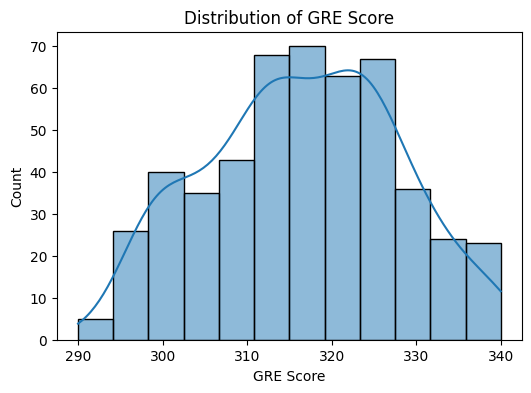

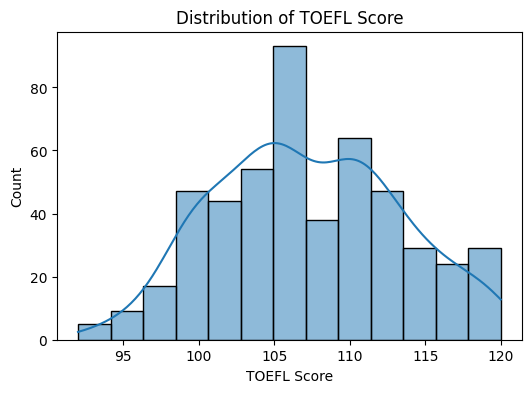

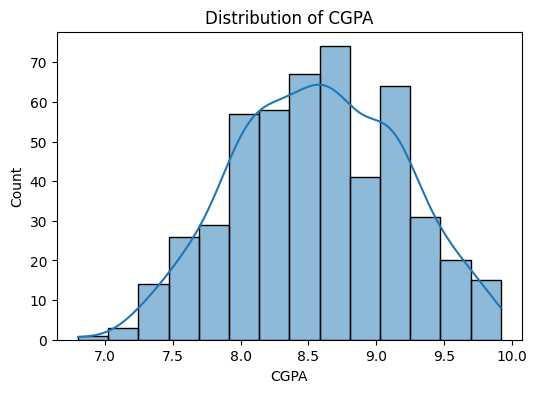

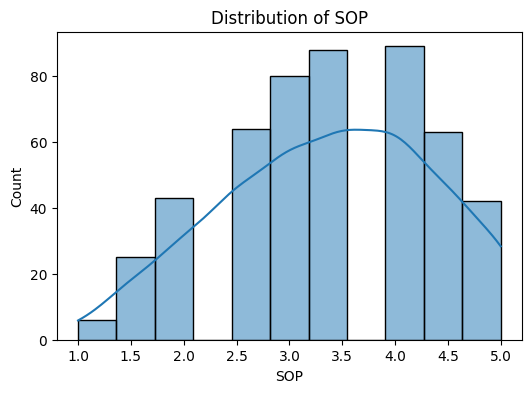

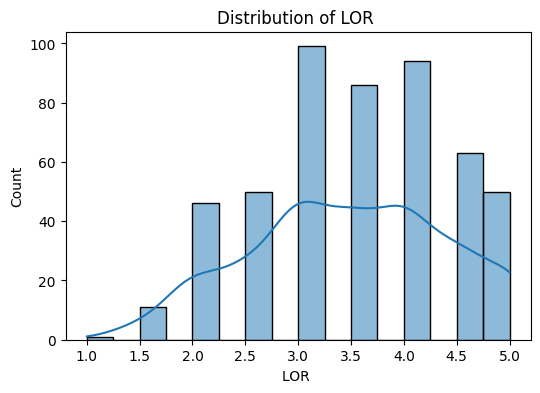

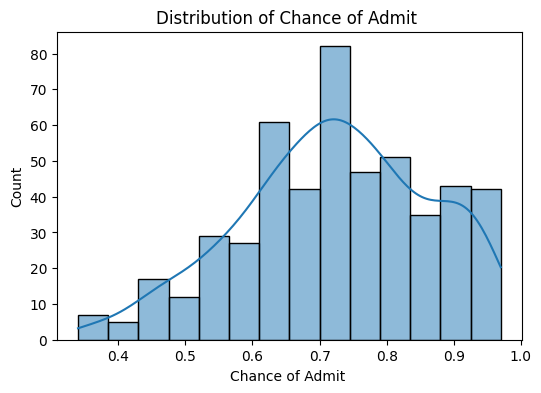

In [16]:
continuous_cols = ["GRE Score", "TOEFL Score", "CGPA", "SOP", "LOR ", "Chance of Admit "]

for col in continuous_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

## Observations
The distribution of GRE Score shows whether applicants are clustered around higher scores or spread across the range.

TOEFL scores help identify English proficiency variation among applicants.

CGPA distribution indicates academic consistency of applicants.

SOP and LOR scores being concentrated toward higher values may indicate subjective evaluation bias.

Chance of Admit distribution confirms whether the dataset contains applicants with varying admission probabilities, validating its suitability for modeling.

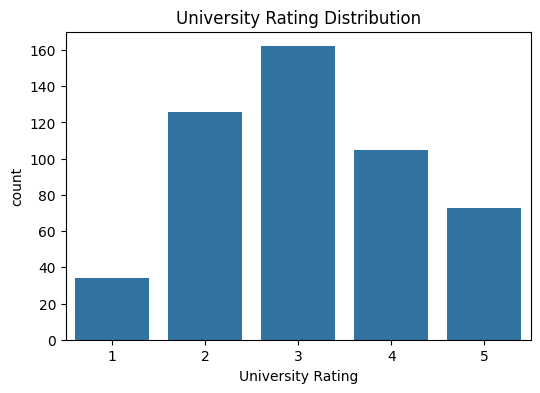

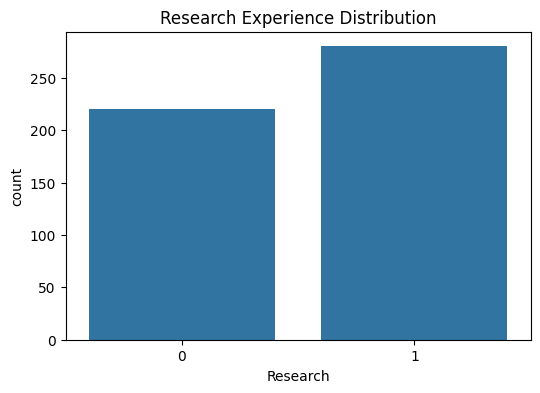

In [17]:
# Count Plots
plt.figure(figsize=(6,4))
sns.countplot(x="University Rating", data=df)
plt.title("University Rating Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x="Research", data=df)
plt.title("Research Experience Distribution")
plt.show()


## Observations
Most applicants tend to apply to mid to high-rated universities.

Research experience distribution shows whether applicants with and without research are balanced.

Any imbalance must be noted as it may influence model learning.

## Outlier Detetction


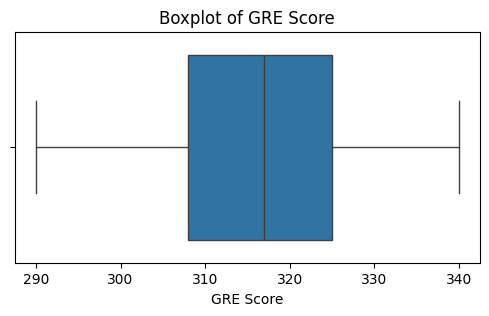

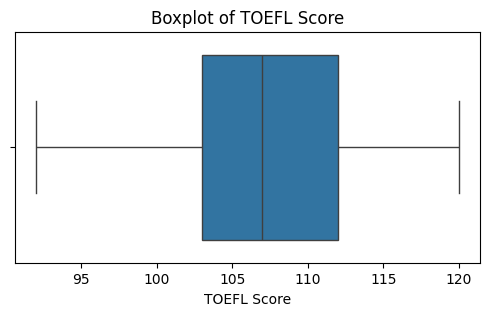

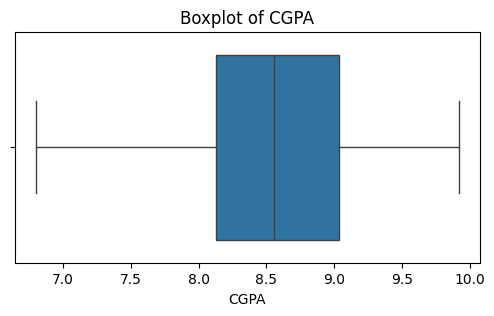

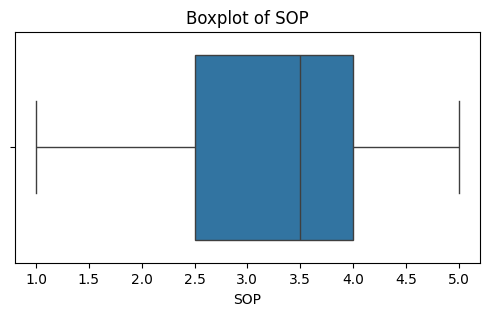

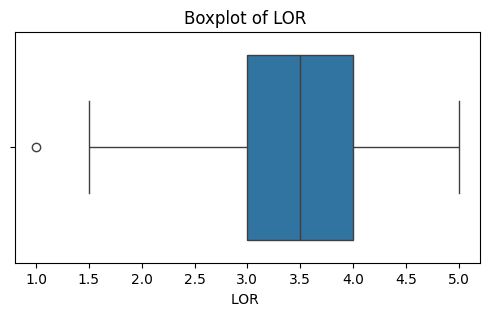

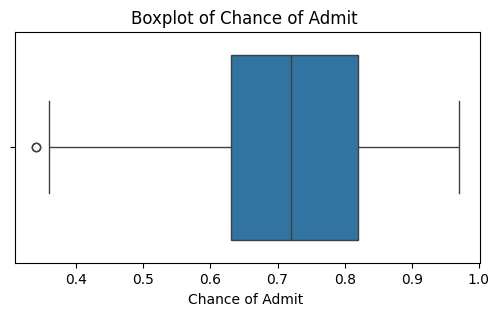

In [18]:
for col in continuous_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


## Bivariate Analysis


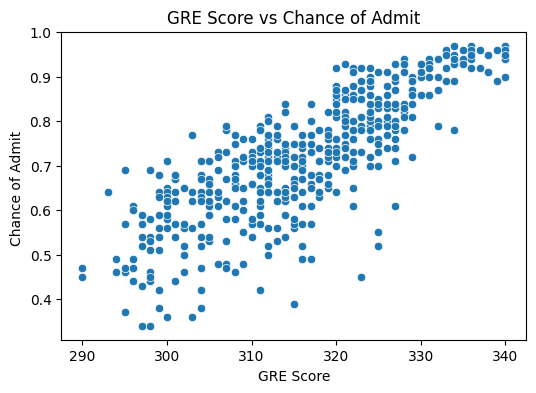

In [20]:
# GRE vs Chance of Admit
plt.figure(figsize=(6,4))
sns.scatterplot(x="GRE Score", y="Chance of Admit ", data=df)
plt.title("GRE Score vs Chance of Admit")
plt.show()


A positive trend suggests higher GRE scores increase admission chances.

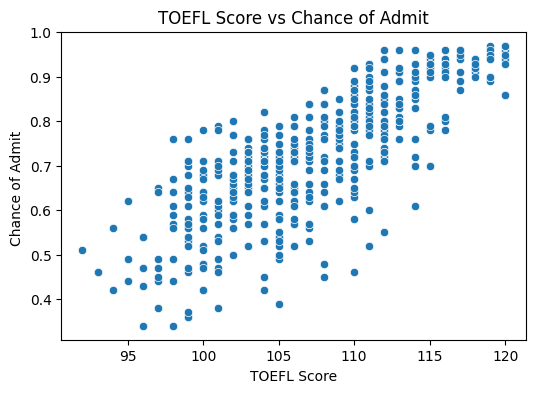

In [23]:
#TOEFL vs Chance of Admit
plt.figure(figsize=(6,4))
sns.scatterplot(x="TOEFL Score", y="Chance of Admit ", data=df)
plt.title("TOEFL Score vs Chance of Admit")
plt.show()


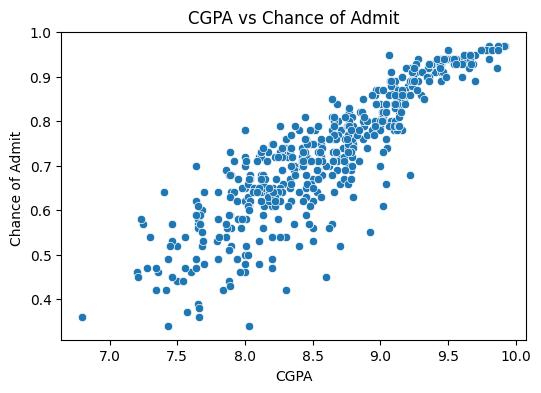

In [26]:
#CGPA vs Chance of Admit
plt.figure(figsize=(6,4))
sns.scatterplot(x="CGPA", y="Chance of Admit ", data=df)
plt.title("CGPA vs Chance of Admit")
plt.show()


CGPA often shows the strongest linear relationship with admission probability.

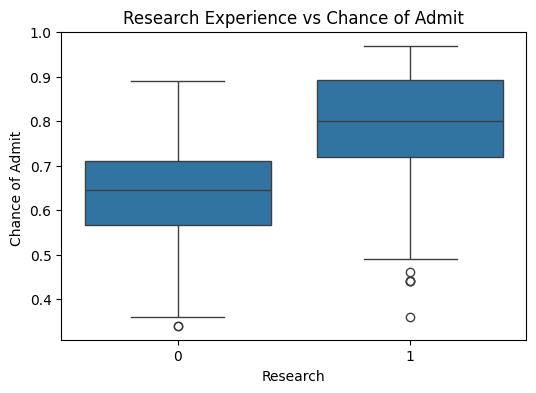

In [29]:
#Research vs Chance of Admit
plt.figure(figsize=(6,4))
sns.boxplot(x="Research", y="Chance of Admit ", data=df)
plt.title("Research Experience vs Chance of Admit")
plt.show()


Applicants with research experience tend to have higher median admission chances.

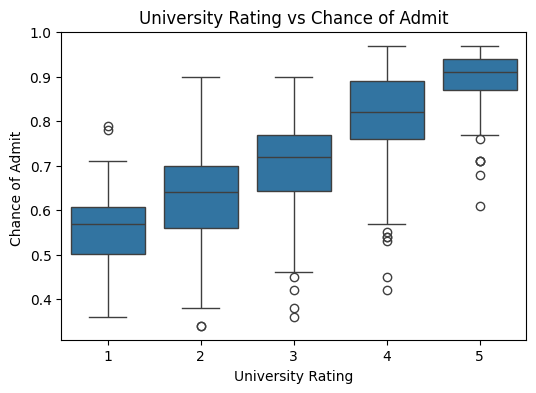

In [32]:
#University Rating vs Chance of Admit
plt.figure(figsize=(6,4))
sns.boxplot(x="University Rating", y="Chance of Admit ", data=df)
plt.title("University Rating vs Chance of Admit")
plt.show()


# Correlation Matrix

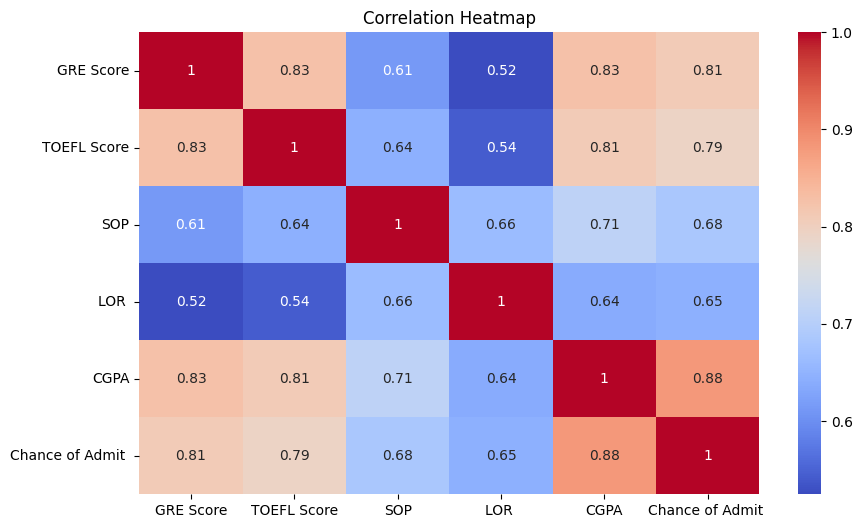

In [33]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Target & Predictors

In [36]:
X = df.drop(columns=["Chance of Admit "])
y = df["Chance of Admit "]


## Train–Test Split

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## MODEL BUILDING

In [39]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train_scaled)
X_test_sm = sm.add_constant(X_test_scaled)


In [40]:
linear_model = sm.OLS(y_train, X_train_sm).fit()

In [41]:
linear_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       Chance of Admit    R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     257.0
Date:                Tue, 27 Jan 2026   Prob (F-statistic):          3.41e-142
Time:                        13:46:10   Log-Likelihood:                 561.91
No. Observations:                 400   AIC:                            -1108.
Df Residuals:                     392   BIC:                            -1076.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7242      0.003    241.441      0.000       0.718       0.730
x1             0.0267      0.006      4.196      0.000       0.014       0.039
x2             0.0182      0.006      3.174      0.002       0.007       0.030
x3             0.0029      0.005      0.611      0.541      -0.007       0.012
x4             0.0018      0.005      0.357      0.721      -0.008       0.012
x5             0.0159      0.004      3.761      0.000       0.008       0.024
x6             0.0676      0.006     10.444      0.000       0.055       0.080
x7             0.0119      0.004      3.231      0.001       0.005       0.019
==============================================================================
Omnibus:                       86.232   Durbin-Watson:                   2.050
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              190.099
Skew:                          -1.107   Prob(JB):                     5.25e-42
Kurtosis:                       5.551   Cond. No.                         5.65
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Display Model Coefficients with Column Names

In [42]:
coeff_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": linear_model.params[1:]  # excluding constant
})

coeff_df.sort_values(by="Coefficient", ascending=False)


,Feature,Coefficient
x6,CGPA,0.067581
x1,GRE Score,0.026671
x2,TOEFL Score,0.018226
x5,LOR,0.015866
x7,Research,0.011940
x3,University Rating,0.002940
x4,SOP,0.001788


Positive coefficients increase admission probability.

CGPA, GRE, and TOEFL usually show higher positive impact.

Research experience dummy variable shows a positive shift in chances.

# Ridge Regression

In [43]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)


Ridge()

In [44]:
ridge_coeff = pd.DataFrame({
    "Feature": X_train.columns,
    "Ridge Coefficient": ridge.coef_
})

ridge_coeff.sort_values(by="Ridge Coefficient", ascending=False)


,Feature,Ridge Coefficient
5,CGPA,0.067011
0,GRE Score,0.026789
1,TOEFL Score,0.018355
4,LOR,0.015893
6,Research,0.011949
2,University Rating,0.003046
3,SOP,0.001937


Ridge regression reduces coefficient magnitudes while retaining all features.

Useful when predictors are correlated.

# Lasso Regression

In [45]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01)
lasso.fit(X_train_scaled, y_train)


Lasso(alpha=0.01)

In [46]:
lasso_coeff = pd.DataFrame({
    "Feature": X_train.columns,
    "Lasso Coefficient": lasso.coef_
})

lasso_coeff.sort_values(by="Lasso Coefficient", ascending=False)


,Feature,Lasso Coefficient
5,CGPA,0.068957
0,GRE Score,0.026240
1,TOEFL Score,0.015137
4,LOR,0.011111
6,Research,0.006099
2,University Rating,0.000919
3,SOP,0.000000


Lasso eliminates weak predictors by shrinking coefficients to zero.

Helps identify the most influential features affecting admissions.

## TESTING LINEAR REGRESSION ASSUMPTIONS

Multicollinearity

In [51]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = pd.DataFrame()
vif_df["Feature"] = ['const'] + list(X_train.columns)
vif_df["VIF"] = [
    variance_inflation_factor(X_train_sm, i)
    for i in range(X_train_sm.shape[1])
]

vif_df

,Feature,VIF
0,const,1.000000
1,GRE Score,4.489983
2,TOEFL Score,3.664298
3,University Rating,2.572110
4,SOP,2.785764
5,LOR,1.977698
6,CGPA,4.654540
7,Research,1.518065


Iterative Removal (if VIF > 5)

In [53]:
X_vif = np.delete(X_train_sm, 1, axis=1)

In [54]:
model = sm.OLS(y_train, X_vif).fit()


VIF was used to detect multicollinearity.

Variables with VIF > 5 were removed iteratively.

Final model has all predictors with acceptable VIF values.

## Mean of Residuals

In [55]:
residuals.mean()


np.float64(-4.056477376224166e-16)

The mean of residuals is approximately zero.

This confirms the absence of systematic bias in predictions.

# Linearity (Residuals vs Fitted Plot)

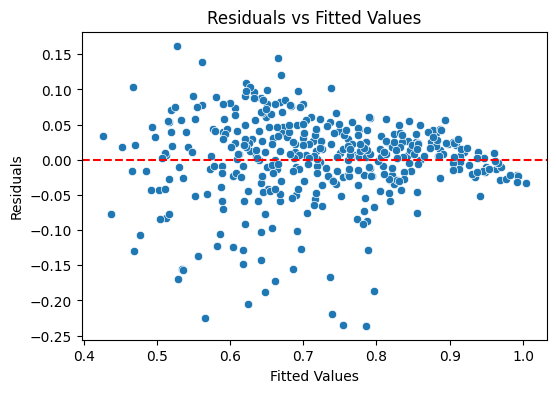

In [56]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=fitted, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()


## Homoscedasticity

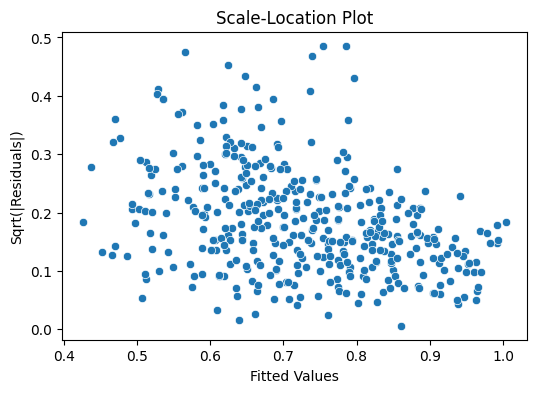

In [57]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=fitted, y=np.sqrt(np.abs(residuals)))
plt.xlabel("Fitted Values")
plt.ylabel("Sqrt(|Residuals|)")
plt.title("Scale-Location Plot")
plt.show()

# Normality of Residuals

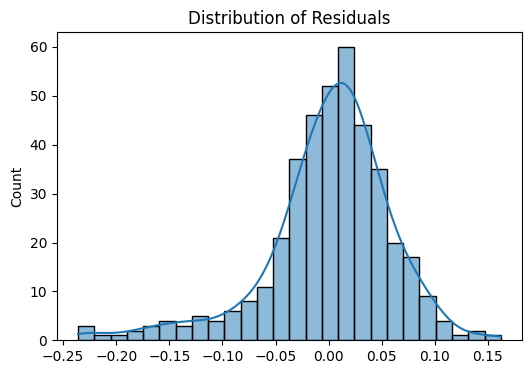

In [58]:
plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title("Distribution of Residuals")
plt.show()


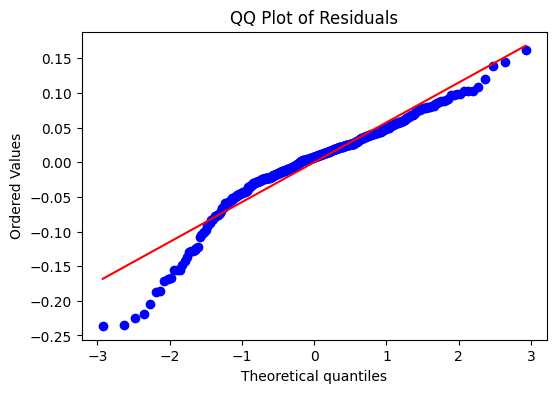

In [59]:
import scipy.stats as stats

plt.figure(figsize=(6,4))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ Plot of Residuals")
plt.show()


# MODEL PERFORMANCE EVALUATION

In [60]:
model = sm.OLS(y_train, X_train_sm).fit()


Predictions on Train & Test Data

In [61]:
y_train_pred = model.predict(X_train_sm)


In [62]:
X_test_sm = sm.add_constant(X_test_scaled)
y_test_pred = model.predict(X_test_sm)


Performance Metrics: MAE, RMSE, R²

In [64]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)



In [65]:
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)


In [66]:
adj_r2 = model.rsquared_adj


In [67]:
performance_df = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2"],
    "Train": [train_mae, train_rmse, train_r2],
    "Test": [test_mae, test_rmse, test_r2]
})

performance_df


,Metric,Train,Test
0,MAE,0.042533,0.042723
1,RMSE,0.059385,0.060866
2,R2,0.821067,0.818843


The model demonstrates strong predictive performance with a high R² value, indicating that a large portion of variance in admission probability is explained by the predictors.

Adjusted R² is close to R², confirming that the model is not overfitting and the included variables are relevant.

Train and test error metrics (MAE and RMSE) are comparable, suggesting good generalization and absence of overfitting.

Low MAE indicates that, on average, the predicted admission probability deviates minimally from actual values.

## Actionable Insights & Recommendations

CGPA is the most important factor in graduate admissions, followed by GRE and TOEFL scores.

Research experience improves admission chances and gives students an edge.

SOP and LOR help but act as supporting factors rather than primary drivers.

Add more data like work experience, internships, and university-specific trends to improve predictions.

Use the model as an admission probability tool to give personalized guidance.